In [ ]:
!pip -q install pandas scikit-learn matplotlib seaborn requests

In [ ]:
import os, io, zipfile, requests, textwrap, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
# 1) Get data
# Tries local CSV first; if missing, downloads from UCI and extracts.
CSV_NAME = "OnlineNewsPopularity.csv"
UCI_ZIP = "https://archive.ics.uci.edu/ml/machine-learning-databases/00332/OnlineNewsPopularity.zip"

def ensure_dataset(csv_name=CSV_NAME):
    if os.path.exists(csv_name):
        return csv_name
    try:
        print("Downloading dataset zip from UCI...")
        r = requests.get(UCI_ZIP, timeout=60)
        r.raise_for_status()
        z = zipfile.ZipFile(io.BytesIO(r.content))
        # Extract CSV to current folder (it may live at root of the zip)
        target_member = None
        for m in z.namelist():
            if m.lower().endswith(".csv"):
                target_member = m
                break
        assert target_member is not None, "CSV not found in zip."
        with z.open(target_member) as f_in, open(csv_name, "wb") as f_out:
            f_out.write(f_in.read())
        print("Saved:", csv_name)
        return csv_name
    except Exception as e:
        raise SystemExit(
            "Could not download dataset automatically.\n"
            "Fix internet and re-run, OR manually place 'OnlineNewsPopularity.csv' in this folder.\n"
            f"Details: {e}"
        )

csv_path = ensure_dataset()

Saved: OnlineNewsPopularity.csv


In [ ]:
# 2) Load data
df_raw = pd.read_csv(csv_path)
df_raw.head(3)

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.5,-0.1875,0.0,0.1875,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.0,0.0000,0.5,0.0000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.0,0.0000,0.5,0.0000,1500


In [ ]:

# ### Basic info & cleaning
# Following the paper: drop technical columns (`url`), standardize later for LR. :contentReference[oaicite:3]{index=3}

# %%
df = df_raw.copy()

# Harmonize column names (some files have spaces in header)
df.columns = [c.strip() for c in df.columns]

drop_cols = [c for c in df.columns if c.lower() in ["url", "timedelta"]]
df.drop(columns=drop_cols, inplace=True, errors="ignore")

# Create binary target: popular if shares >= 1400 (median per paper) :contentReference[oaicite:4]{index=4}
df["popular"] = (df["shares"] >= 1400).astype(int)
df.drop(columns=["shares"], inplace=True)

print("Shape:", df.shape)
df.head(5)

Shape: (39644, 59)


,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,popular
0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,4.680365,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,0
1,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,4.913725,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,0
2,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,4.393365,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1
3,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,4.404896,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,0
4,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,0.0,4.682836,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,0


'No missing values detected.'

Class counts (0=not popular, 1=popular):


,count
popular,
0,18490
1,21154


Class ratio (1s): 0.534


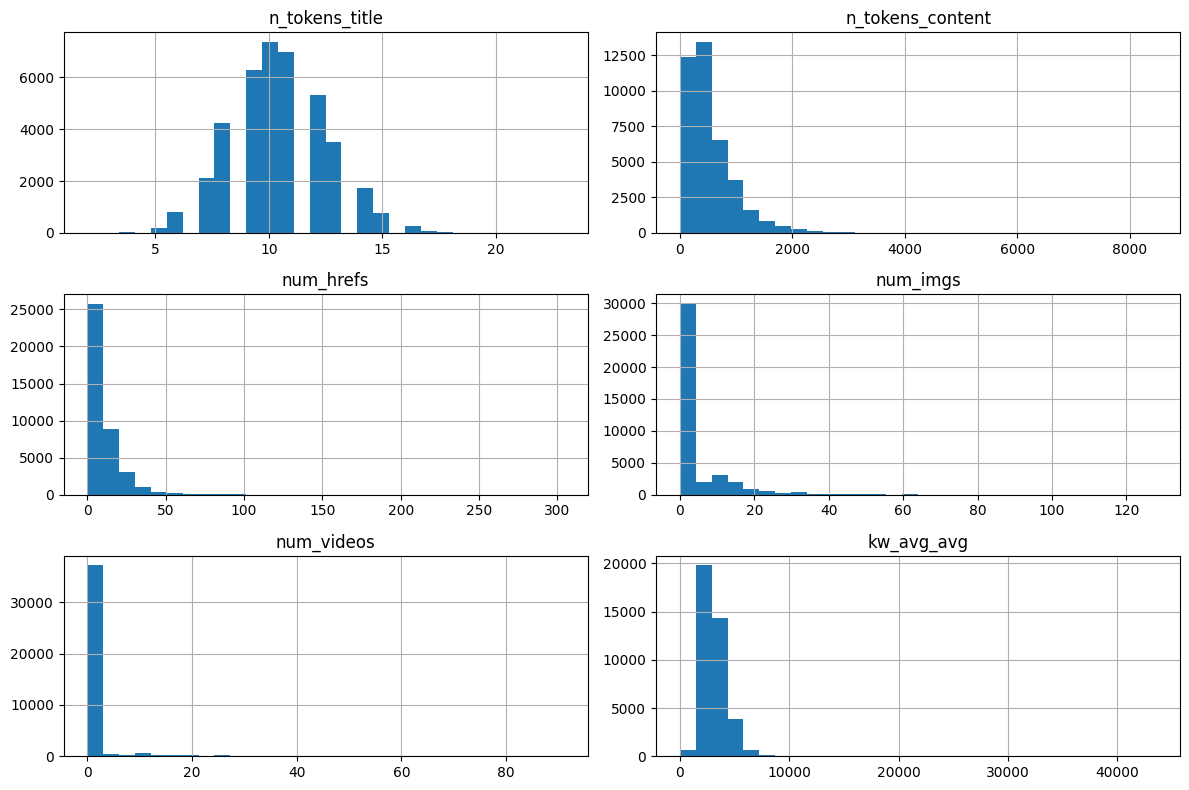

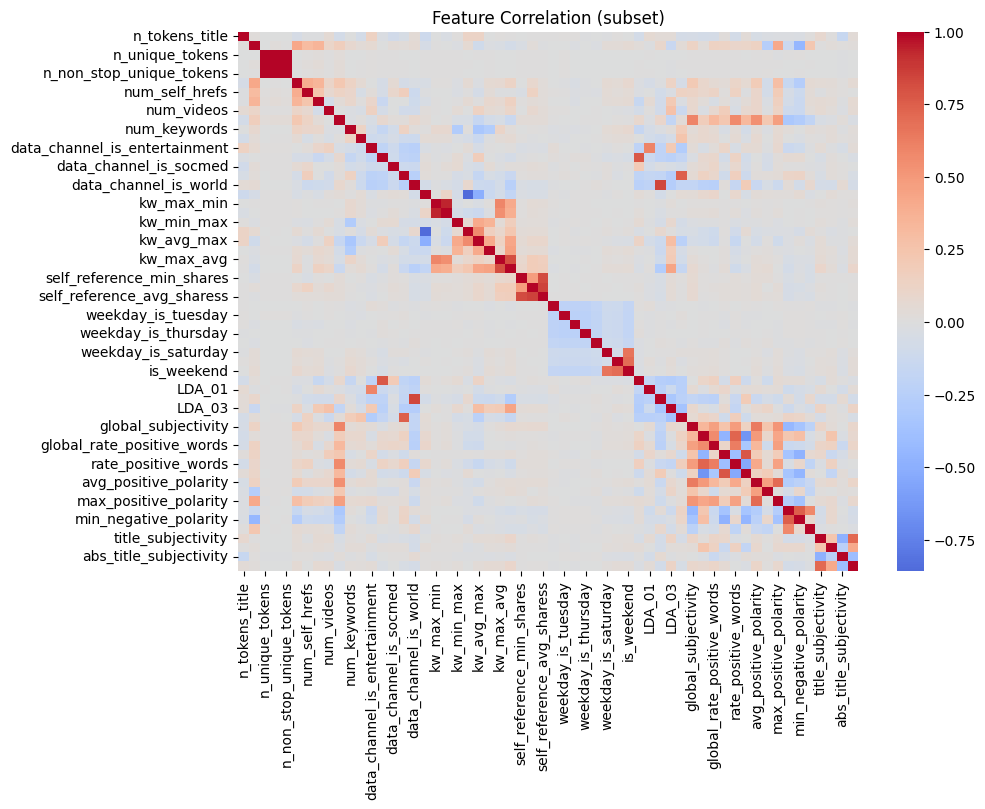

In [ ]:

# ### Quick EDA

# %%
# Missing values check
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing>0] if missing.sum() else "No missing values detected.")

# Class balance
class_counts = df["popular"].value_counts().sort_index()
print("Class counts (0=not popular, 1=popular):")
display(class_counts)
print("Class ratio (1s):", round(class_counts.get(1,0)/class_counts.sum(), 3))

# Basic distribution plots for a few intuitive features (if present)
cand_cols = [c for c in [
    "n_tokens_title", "n_tokens_content", "num_hrefs", "num_imgs", "num_videos",
    "kw_avg_avg", "data_channel_is_entertainment", "is_weekend"
] if c in df.columns][:6]

if cand_cols:
    df[cand_cols].hist(bins=30, figsize=(12,8))
    plt.tight_layout(); plt.show()

# Correlation (numeric) heatmap (quick glance)
corr = df.drop(columns=["popular"]).corr(numeric_only=True)
plt.figure(figsize=(10,7))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation (subset)")
plt.show()

In [ ]:

# ## 3) Train / Test split

# %%
X = df.drop(columns=["popular"])
y = df["popular"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

X_train.shape, X_test.shape

((31715, 58), (7929, 58))

== Logistic Regression (Balanced) ==
Accuracy: 0.6549 | Precision: 0.6895 | Recall: 0.6429 | F1: 0.6654 | ROC-AUC: 0.7073

Classification report:
               precision    recall  f1-score   support

           0       0.62      0.67      0.64      3698
           1       0.69      0.64      0.67      4231

    accuracy                           0.65      7929
   macro avg       0.66      0.66      0.65      7929
weighted avg       0.66      0.65      0.66      7929



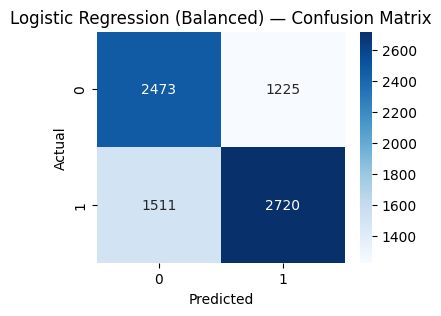

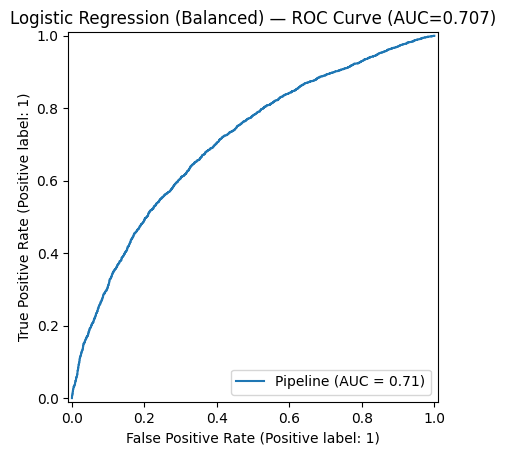

== Random Forest (Balanced) ==
Accuracy: 0.6609 | Precision: 0.6654 | Recall: 0.7332 | F1: 0.6976 | ROC-AUC: 0.7215

Classification report:
               precision    recall  f1-score   support

           0       0.65      0.58      0.61      3698
           1       0.67      0.73      0.70      4231

    accuracy                           0.66      7929
   macro avg       0.66      0.66      0.66      7929
weighted avg       0.66      0.66      0.66      7929



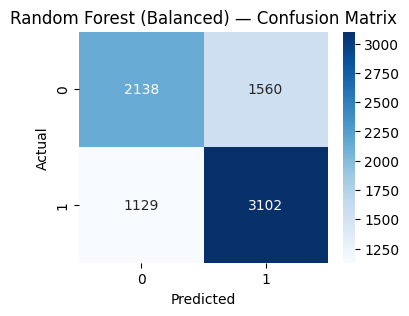

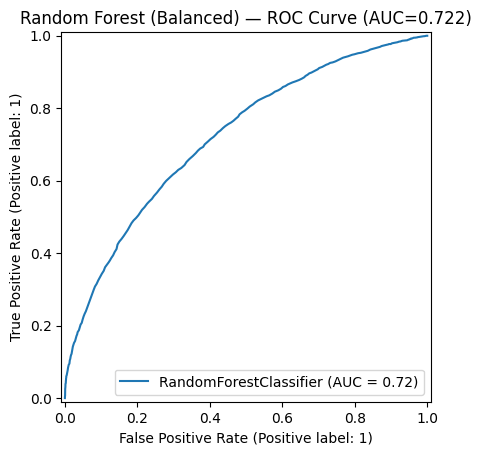

In [ ]:

# ## 4) Baseline Models
# We'll train:
# - **Logistic Regression** (with StandardScaler in a Pipeline)
# - **Random Forest** (trees don't need scaling)
#
# (Paper shows these as core baselines alongside others. :contentReference[oaicite:5]{index=5})

# %%
def evaluate(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)
    # If model has predict_proba, compute AUC
    try:
        y_proba = model.predict_proba(X_test)[:,1]
        auc = roc_auc_score(y_test, y_proba)
    except Exception:
        auc = np.nan

    acc = accuracy_score(y_test, y_pred)
    pr, rc, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary", zero_division=0)

    print(f"== {name} ==")
    print(f"Accuracy: {acc:.4f} | Precision: {pr:.4f} | Recall: {rc:.4f} | F1: {f1:.4f} | ROC-AUC: {auc:.4f}")
    print("\nClassification report:\n", classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} — Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.show()

    # ROC curve (if proba available)
    if not np.isnan(auc):
        RocCurveDisplay.from_estimator(model, X_test, y_test)
        plt.title(f"{name} — ROC Curve (AUC={auc:.3f})")
        plt.show()

# %%
# Logistic Regression (balanced weights to handle class skew *without* SMOTE)
pipe_lr = Pipeline(steps=[
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("lr", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
])
pipe_lr.fit(X_train, y_train)
evaluate(pipe_lr, X_test, y_test, name="Logistic Regression (Balanced)")

# %%
# Random Forest (also try class_weight balanced)
rf = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_split=2, min_samples_leaf=1,
    class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE
)
rf.fit(X_train, y_train)
evaluate(rf, X_test, y_test, name="Random Forest (Balanced)")

In [ ]:

# ## 5) Cross-validation (quick)
# Gives a more stable sense of performance on the training set.

# %%
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in [
    ("LogReg", pipe_lr),
    ("RandForest", rf),
]:
    cv_f1 = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1")
    cv_acc = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    print(f"{name} | CV F1: {cv_f1.mean():.3f} ± {cv_f1.std():.3f} | CV Acc: {cv_acc.mean():.3f} ± {cv_acc.std():.3f}")

LogReg | CV F1: 0.663 ± 0.005 | CV Acc: 0.652 ± 0.003
RandForest | CV F1: 0.708 ± 0.004 | CV Acc: 0.673 ± 0.004


,0
kw_avg_avg,0.043937
kw_max_avg,0.041143
LDA_02,0.032315
self_reference_min_shares,0.031268
LDA_04,0.030266
LDA_01,0.029934
LDA_00,0.029438
kw_avg_min,0.029285
kw_avg_max,0.029250
self_reference_avg_sharess,0.028440


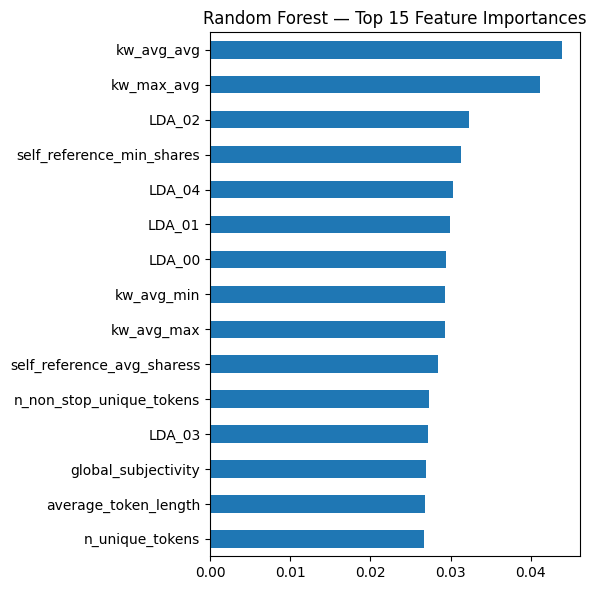

,0
n_non_stop_words,1.503915
n_non_stop_unique_tokens,1.177357
kw_avg_avg,0.963616
kw_max_avg,0.578216
n_unique_tokens,0.294663
data_channel_is_tech,0.204782
LDA_00,0.203930
data_channel_is_socmed,0.194156
kw_avg_min,0.157187
kw_max_min,0.143152


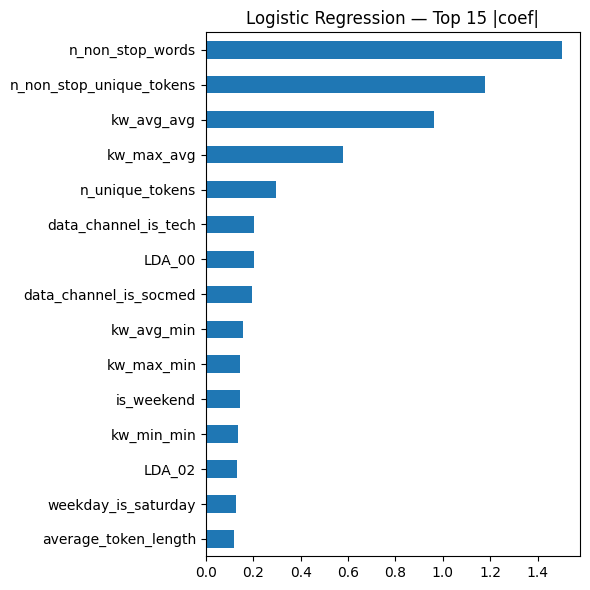

In [ ]:
# ## 6) Feature importance / coefficients
# - RF: Gini importances
# - LR: coefficients on standardized features

# %%
# Random Forest importances
if hasattr(rf, "feature_importances_"):
    imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
    display(imp.head(15))
    plt.figure(figsize=(6,6))
    imp.head(15).sort_values().plot.barh()
    plt.title("Random Forest — Top 15 Feature Importances")
    plt.tight_layout(); plt.show()

# Logistic Regression coefficients (absolute)
try:
    # Pull the trained inner estimator from pipeline
    lr_coef = pipe_lr.named_steps["lr"].coef_.ravel()
    lr_imp = pd.Series(np.abs(lr_coef), index=X.columns).sort_values(ascending=False)
    display(lr_imp.head(15))
    plt.figure(figsize=(6,6))
    lr_imp.head(15).sort_values().plot.barh()
    plt.title("Logistic Regression — Top 15 |coef|")
    plt.tight_layout(); plt.show()
except Exception as e:
    print("Could not compute LR coefficients:", e)


In [ ]:
# ## 7) Save models (optional)
# These can be loaded later for a small Streamlit demo without retraining.

# %%
import joblib
joblib.dump(pipe_lr, "model_logreg_balanced.joblib")
joblib.dump(rf, "model_random_forest_balanced.joblib")
print("Saved models to disk.")


Saved models to disk.
